In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from dotenv import load_dotenv
load_dotenv('../.env')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from src.db import read_sql

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})
BLEU   = '#1565C0'
ROUGE  = '#C62828'
VERT   = '#2E7D32'
ORANGE = '#E65100'
VIOLET = '#6A1B9A'

# Réformes clés pour annotations
REFORMES = [
    (1993, 'Balladur'),
    (2003, 'Fillon'),
    (2010, 'Woerth'),
    (2014, 'Touraine'),
    (2023, 'Borne'),
]
print('OK')

OK


# 08 — DREES : Panorama tous régimes
Analyses issues du panorama DREES *Les retraités et les retraites* (édition 2025, données 2023).  
Source : DREES, EIR, modèle ANCETRE — Licence Ouverte v2.0

In [2]:
# Chargement de toutes les données DREES depuis SQL
df_drees = read_sql("""
    SELECT annee, genre_code, indicateur,
           CAST(valeur AS FLOAT) AS valeur, unite
    FROM ext.DREES_PensionsMultiRegimes
    WHERE source_fichier = 'DREES_PANORAMA_2025'
    ORDER BY indicateur, annee, genre_code
""")

def pivot_indicateur(indic, genre='T'):
    d = df_drees[(df_drees.indicateur == indic) & (df_drees.genre_code == genre)]
    return d.sort_values('annee').set_index('annee')['valeur']

print(df_drees.groupby('indicateur')[['annee','valeur']].agg({'annee':['min','max'],'valeur':'count'}))

                          annee       valeur
                            min   max  count
indicateur                                  
AGE_CONJONCTUREL_DEPART    2004  2023     60
EVOL_NB_RETRAITES_PCT      2005  2023     16
NB_RETRAITES_TOUS_REGIMES  2004  2023     60
NOUVEAUX_RETRAITES         2005  2023     19
PART_DDE_PIB_PCT           1990  2023     34
PART_DD_PIB_PCT            1990  2023     34
PART_TOTAL_PIB_PCT         1990  2023     34
PRESTATIONS_DDE_MDS_EUR    1990  2023     34
PRESTATIONS_DD_MDS_EUR     1990  2023     34
PRESTATIONS_TOTAL_MDS_EUR  1990  2023     34
VARIATION_NB_RETRAITES     2005  2023     16


## 1. Effectifs de retraités tous régimes (2004–2023)

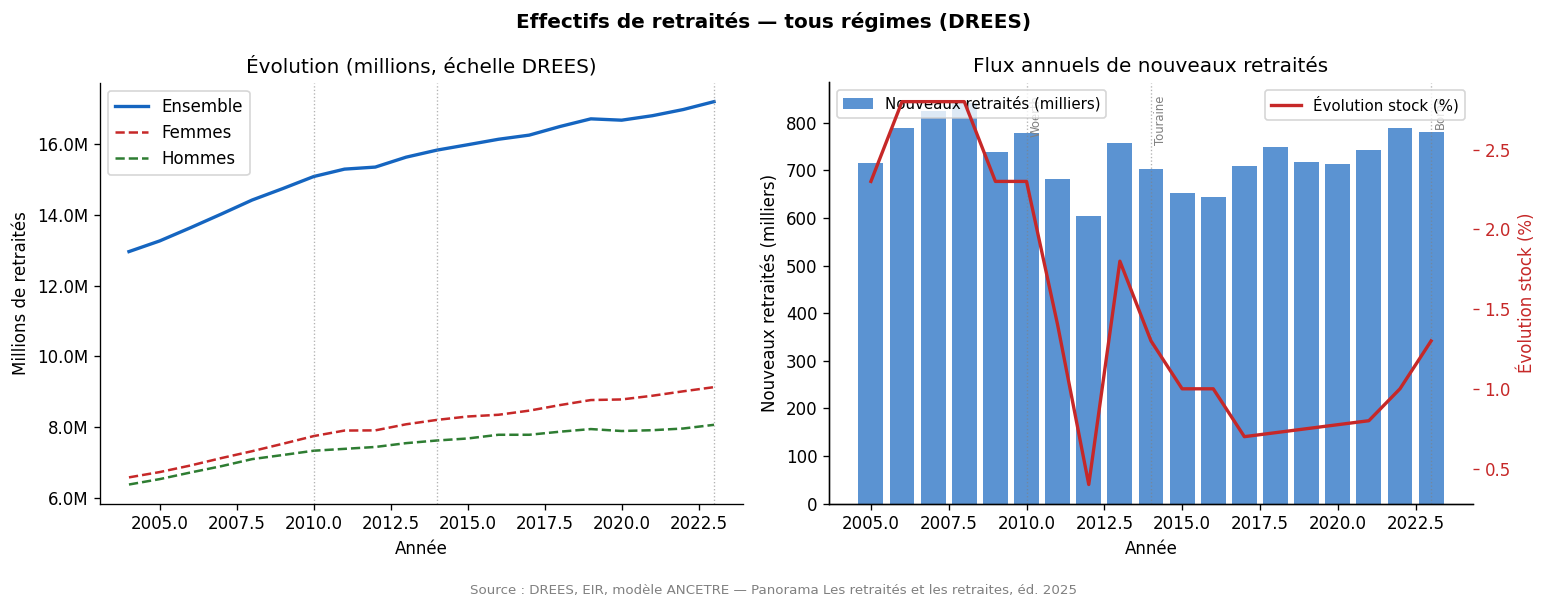

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Effectifs de retraités — tous régimes (DREES)', fontsize=12, fontweight='bold')

# A : Évolution H/F/T
ax = axes[0]
for gc, col, lbl in [('T', BLEU, 'Ensemble'), ('F', ROUGE, 'Femmes'), ('H', VERT, 'Hommes')]:
    s = pivot_indicateur('NB_RETRAITES_TOUS_REGIMES', gc)
    ax.plot(s.index, s / 1000, color=col, lw=2 if gc == 'T' else 1.5,
            ls='-' if gc == 'T' else '--', label=lbl)
ax.set_title('Évolution (millions, échelle DREES)')
ax.set_ylabel('Millions de retraités')
ax.set_xlabel('Année')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))
for annee_r, nom_r in REFORMES:
    if 2004 <= annee_r <= 2023:
        ax.axvline(annee_r, color='gray', ls=':', lw=0.8, alpha=0.6)

# B : Flux nouveaux retraités
ax = axes[1]
s_nv = pivot_indicateur('NOUVEAUX_RETRAITES', 'T')
ax.bar(s_nv.index, s_nv, color=BLEU, alpha=0.7, label='Nouveaux retraités (milliers)')
ax2 = ax.twinx()
s_ev = pivot_indicateur('EVOL_NB_RETRAITES_PCT', 'T')
ax2.plot(s_ev.index, s_ev, color=ROUGE, lw=2, label='Évolution stock (%)')
ax2.set_ylabel('Évolution stock (%)', color=ROUGE)
ax2.tick_params(axis='y', colors=ROUGE)
ax.set_title('Flux annuels de nouveaux retraités')
ax.set_xlabel('Année')
ax.set_ylabel('Nouveaux retraités (milliers)')
ax.legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)
for annee_r, nom_r in REFORMES:
    if 2004 <= annee_r <= 2023:
        ax.axvline(annee_r, color='gray', ls=':', lw=0.8, alpha=0.6)
        ax.text(annee_r + 0.1, ax.get_ylim()[1]*0.97, nom_r, fontsize=7, color='gray', rotation=90, va='top')

fig.text(0.5, 0.01, 'Source : DREES, EIR, modèle ANCETRE — Panorama Les retraités et les retraites, éd. 2025',
         ha='center', fontsize=8, color='gray')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('reports/08_effectifs_tous_regimes.png', bbox_inches='tight')
plt.show()

## 2. Âge conjoncturel moyen de départ à la retraite (2004–2023)

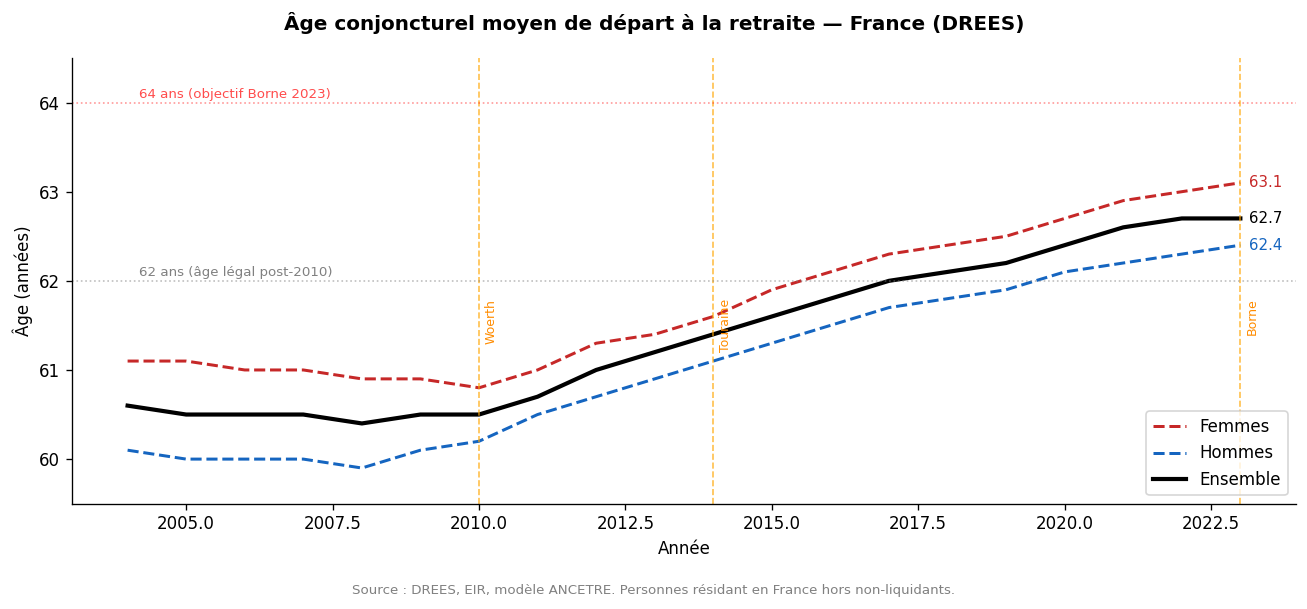

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
fig.suptitle('Âge conjoncturel moyen de départ à la retraite — France (DREES)', fontsize=12, fontweight='bold')

for gc, col, lbl in [('F', ROUGE, 'Femmes'), ('H', BLEU, 'Hommes'), ('T', 'black', 'Ensemble')]:
    s = pivot_indicateur('AGE_CONJONCTUREL_DEPART', gc)
    ax.plot(s.index, s, color=col, lw=2.5 if gc == 'T' else 1.8,
            ls='-' if gc == 'T' else '--', label=lbl)
    ax.annotate(f"{s.iloc[-1]:.1f}", xy=(s.index[-1], s.iloc[-1]),
                xytext=(5, 0), textcoords='offset points', color=col, fontsize=9, va='center')

# Annotations réformes
for annee_r, nom_r in REFORMES:
    if 2004 <= annee_r <= 2023:
        ax.axvline(annee_r, color='orange', ls='--', lw=1, alpha=0.7)
        ax.text(annee_r + 0.1, 61.8, nom_r, fontsize=7.5, color='darkorange', rotation=90, va='top')

# Seuil de 62 ans (âge légal post-Woerth)
ax.axhline(62, color='gray', ls=':', lw=1, alpha=0.5)
ax.text(2004.2, 62.05, '62 ans (âge légal post-2010)', fontsize=8, color='gray')
# Seuil de 64 ans (Borne)
ax.axhline(64, color='red', ls=':', lw=1, alpha=0.4)
ax.text(2004.2, 64.05, '64 ans (objectif Borne 2023)', fontsize=8, color='red', alpha=0.7)

ax.set_xlabel('Année')
ax.set_ylabel('Âge (années)')
ax.set_ylim(59.5, 64.5)
ax.legend()
fig.text(0.5, 0.01, 'Source : DREES, EIR, modèle ANCETRE. Personnes résidant en France hors non-liquidants.',
         ha='center', fontsize=8, color='gray')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('reports/08_age_depart_retraite.png', bbox_inches='tight')
plt.show()

## 3. Masses financières et part du PIB (1990–2023)

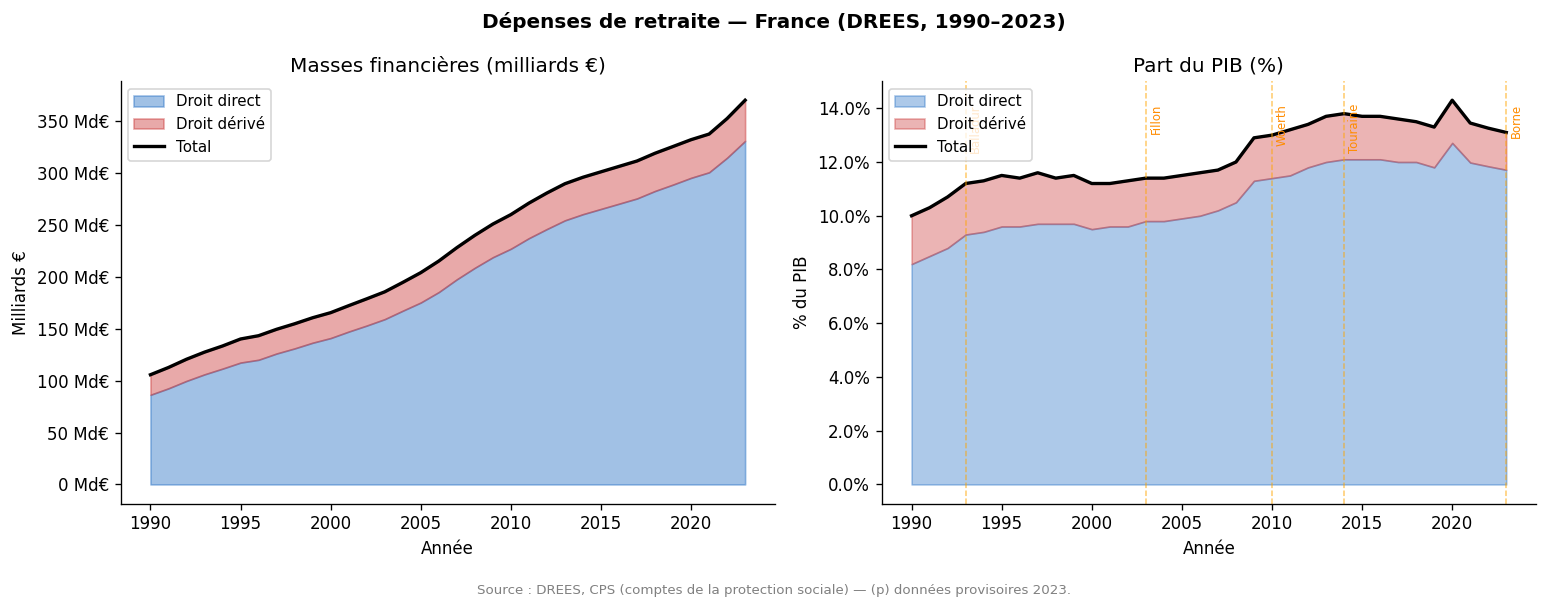

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Dépenses de retraite — France (DREES, 1990–2023)', fontsize=12, fontweight='bold')

# A : Montants en milliards d'euros
ax = axes[0]
tot = pivot_indicateur('PRESTATIONS_TOTAL_MDS_EUR', 'T')
dd  = pivot_indicateur('PRESTATIONS_DD_MDS_EUR',    'T')
dde = pivot_indicateur('PRESTATIONS_DDE_MDS_EUR',   'T')
ax.fill_between(dd.index,  dd,       alpha=0.4, color=BLEU,  label='Droit direct')
ax.fill_between(dde.index, dd + dde, dd, alpha=0.4, color=ROUGE, label='Droit dérivé')
ax.plot(tot.index, tot, color='black', lw=2, label='Total')
ax.set_title('Masses financières (milliards €)')
ax.set_xlabel('Année')
ax.set_ylabel('Milliards €')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f} Md€"))

# B : Part du PIB
ax = axes[1]
tot_pib = pivot_indicateur('PART_TOTAL_PIB_PCT', 'T')
dd_pib  = pivot_indicateur('PART_DD_PIB_PCT',    'T')
ax.fill_between(dd_pib.index,  dd_pib,        alpha=0.35, color=BLEU,  label='Droit direct')
ax.fill_between(tot_pib.index, tot_pib, dd_pib, alpha=0.35, color=ROUGE, label='Droit dérivé')
ax.plot(tot_pib.index, tot_pib, color='black', lw=2, label='Total')
for annee_r, nom_r in REFORMES:
    if 1990 <= annee_r <= 2023:
        ax.axvline(annee_r, color='orange', ls='--', lw=0.9, alpha=0.6)
        ax.text(annee_r + 0.2, tot_pib.max()*0.99, nom_r, fontsize=7, color='darkorange', rotation=90, va='top')
ax.set_title('Part du PIB (%)')
ax.set_xlabel('Année')
ax.set_ylabel('% du PIB')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))

fig.text(0.5, 0.01, 'Source : DREES, CPS (comptes de la protection sociale) — (p) données provisoires 2023.',
         ha='center', fontsize=8, color='gray')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('reports/08_masses_financieres.png', bbox_inches='tight')
plt.show()

## 4. Croisement CNAV × DREES — part CNAV dans le système

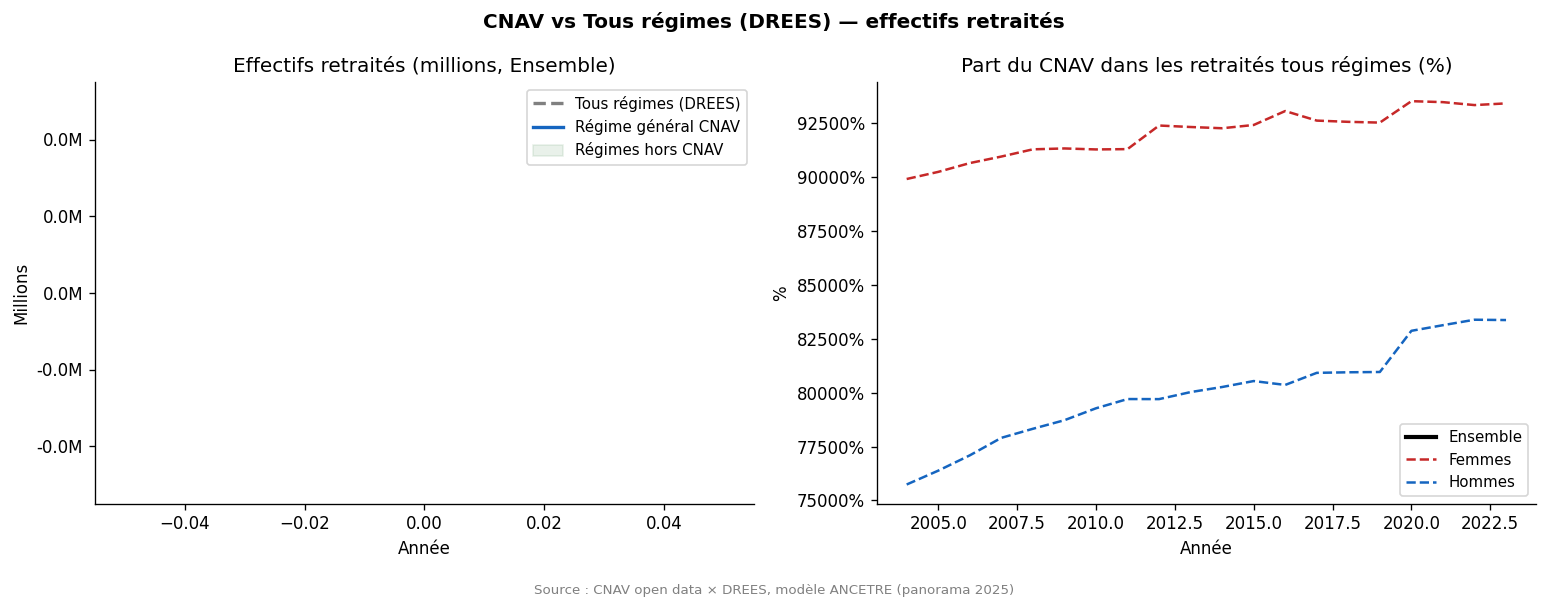

In [6]:
# Effectifs CNAV (fact.*) vs tous régimes (DREES)
df_cnav_t = read_sql("""
    SELECT a.annee,
           g.code AS genre_code,
           CAST(SUM(e.nb_retraites) AS FLOAT) / 1000.0 AS nb_retraites_cnav_M
    FROM fact.RetraitesEffectifs e
    JOIN dim.Annee a  ON a.annee_id  = e.annee_id
    JOIN dim.Genre g  ON g.genre_id  = e.genre_id
    JOIN dim.CARSAT c ON c.carsat_id = e.carsat_id AND c.code = 'TOTAL'
    WHERE g.code IN ('H','F','T') AND a.annee >= 2004
    GROUP BY a.annee, g.code
""")

df_drees_eff = df_drees[
    (df_drees.indicateur == 'NB_RETRAITES_TOUS_REGIMES')
].rename(columns={'valeur': 'nb_retraites_drees_M'})
df_drees_eff['nb_retraites_drees_M'] /= 1000

df_compare = df_cnav_t.merge(
    df_drees_eff[['annee','genre_code','nb_retraites_drees_M']],
    on=['annee','genre_code'], how='inner'
)
df_compare['part_cnav_pct'] = (df_compare['nb_retraites_cnav_M'] /
                                df_compare['nb_retraites_drees_M'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('CNAV vs Tous régimes (DREES) — effectifs retraités', fontsize=12, fontweight='bold')

# A : Comparaison effectifs ensemble
ax = axes[0]
ens = df_compare[df_compare.genre_code == 'T'].sort_values('annee')
ax.plot(ens.annee, ens.nb_retraites_drees_M, color='gray',  lw=2, ls='--', label='Tous régimes (DREES)')
ax.plot(ens.annee, ens.nb_retraites_cnav_M,  color=BLEU,   lw=2, label='Régime général CNAV')
ax.fill_between(ens.annee, ens.nb_retraites_cnav_M, ens.nb_retraites_drees_M,
                alpha=0.1, color=VERT, label='Régimes hors CNAV')
ax.set_title('Effectifs retraités (millions, Ensemble)')
ax.set_xlabel('Année')
ax.set_ylabel('Millions')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))

# B : Part CNAV par genre
ax = axes[1]
for gc, col, lbl in [('T','black','Ensemble'),('F',ROUGE,'Femmes'),('H',BLEU,'Hommes')]:
    sub = df_compare[df_compare.genre_code == gc].sort_values('annee')
    ax.plot(sub.annee, sub.part_cnav_pct, color=col,
            lw=2.5 if gc == 'T' else 1.5,
            ls='-' if gc == 'T' else '--', label=lbl)
ax.set_title('Part du CNAV dans les retraités tous régimes (%)')
ax.set_xlabel('Année')
ax.set_ylabel('%')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

fig.text(0.5, 0.01, 'Source : CNAV open data × DREES, modèle ANCETRE (panorama 2025)',
         ha='center', fontsize=8, color='gray')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('reports/08_cnav_vs_tous_regimes.png', bbox_inches='tight')
plt.show()

## 5. Synthèse — tableau de bord 2023

In [7]:
# KPIs 2023
kpi = {}
for indic in df_drees.indicateur.unique():
    sub = df_drees[(df_drees.indicateur == indic) & (df_drees.genre_code == 'T')].sort_values('annee')
    if not sub.empty:
        kpi[indic] = sub.iloc[-1][['annee', 'valeur', 'unite']].to_dict()

print("\n=== Tableau de bord DREES — Dernières valeurs disponibles ===")
print(f"{'Indicateur':<35} {'Année':>5} {'Valeur':>12} {'Unité'}")
print('-' * 70)
for indic, v in sorted(kpi.items()):
    print(f"{indic:<35} {int(v['annee']):>5} {v['valeur']:>12.2f} {v['unite']}")

# Focus effectifs 2023 par sexe
print("\n=== Effectifs retraités 2023 — tous régimes ===")
for gc in ['F','H','T']:
    sub = df_drees[(df_drees.indicateur=='NB_RETRAITES_TOUS_REGIMES') &
                   (df_drees.genre_code==gc) & (df_drees.annee==2023)]
    if not sub.empty:
        v = sub.iloc[0].valeur / 1000
        lbl = {'F':'Femmes','H':'Hommes','T':'Ensemble'}[gc]
        print(f"  {lbl:10}: {v:.2f} millions")


=== Tableau de bord DREES — Dernières valeurs disponibles ===
Indicateur                          Année       Valeur Unité
----------------------------------------------------------------------
AGE_CONJONCTUREL_DEPART              2023        62.70 annees
EVOL_NB_RETRAITES_PCT                2023         1.30 %
NB_RETRAITES_TOUS_REGIMES            2023     17198.00 milliers
NOUVEAUX_RETRAITES                   2023       781.30 milliers
PART_DDE_PIB_PCT                     2023         1.39 %
PART_DD_PIB_PCT                      2023        11.71 %
PART_TOTAL_PIB_PCT                   2023        13.10 %
PRESTATIONS_DDE_MDS_EUR              2023        39.22 milliards_eur
PRESTATIONS_DD_MDS_EUR               2023       330.64 milliards_eur
PRESTATIONS_TOTAL_MDS_EUR            2023       369.86 milliards_eur
VARIATION_NB_RETRAITES               2023       222.90 milliers

=== Effectifs retraités 2023 — tous régimes ===
  Femmes    : 9.13 millions
  Hommes    : 8.07 millions
  Ensemble 